In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200

from botorch.utils.multi_objective.box_decompositions.dominated import DominatedPartitioning

In [2]:
def loadData():
    return np.concatenate(
        [np.load('data/data_initial.npy'),
        np.load('data/data_iter1.npy'),
        np.load('data/data_iter2.npy')], 
        axis = 0
    )

In [3]:
def paretoPlotHelper(bounds):
    pareto_front = torch.empty(bounds.shape[0]*2 + 1, 2)
    for i in range(bounds.shape[0]):
        if i == 0:
            pareto_front[0] = torch.tensor([0, bounds[i, 1]])
            pareto_front[2*i + 1] = torch.tensor([bounds[i, 0], bounds[i, 1]])
        else:
            pareto_front[2*i + 1] = torch.tensor([bounds[i, 0], bounds[i, 1]])
        if i == bounds.shape[0] - 1:
            pareto_front[2*i + 2] = torch.tensor([bounds[i, 0], bounds[i, 1]])
            pareto_front[-1] = torch.tensor([bounds[i, 0], 0])
        else:
            pareto_front[2*i + 2] = torch.tensor([bounds[i, 0], bounds[i+1, 1]])
    return pareto_front

def plotPareto(f1, f2, hv = False):
    color = 'orange'
    fig = plt.figure()
    ax = fig.add_subplot()
    # First plot all the points
    ax.scatter(f1, f2, c = 'black', alpha = 0.5, label = 'All Points')
    # Now plot the pareto points
    Y = torch.cat([torch.tensor(f1).unsqueeze(-1), torch.tensor(f2).unsqueeze(-1)], dim = -1)
    partitioning = DominatedPartitioning(ref_point = torch.tensor([0, -1]), Y = Y)
    pareto_Y = partitioning.pareto_Y
    ax.scatter(pareto_Y[:, 0], pareto_Y[:, 1], c = color, label = 'Pareto Points')
    # Plot the pareto frontier
    bounds = partitioning.get_hypercell_bounds()
    front = paretoPlotHelper(bounds[1])
    ax.plot(front[:, 0], front[:, 1], linestyle = '-', c = color, label = 'Pareto Frontier')
    if hv:
        for i in range(len(pareto_Y)):
            ax.fill(
                [bounds[0,i,0], bounds[1,i,0], bounds[1,i,0], bounds[0,i,0]],
                [bounds[0,i,1], bounds[0,i,1], bounds[1,i,1], bounds[1,i,1]],
                facecolor = color,
                alpha = 0.20,
                label = 'Hypervolume' if i == 0 else None
            )
        ax.set_title(f'Hypervolume = {partitioning.compute_hypervolume():.3f}')
    else:
        ax.set_title('Pareto Frontier')
    ax.legend()
    ax.set_xlabel('Total Concentration (M)')
    ax.set_ylabel('% Viability')
    plt.show()

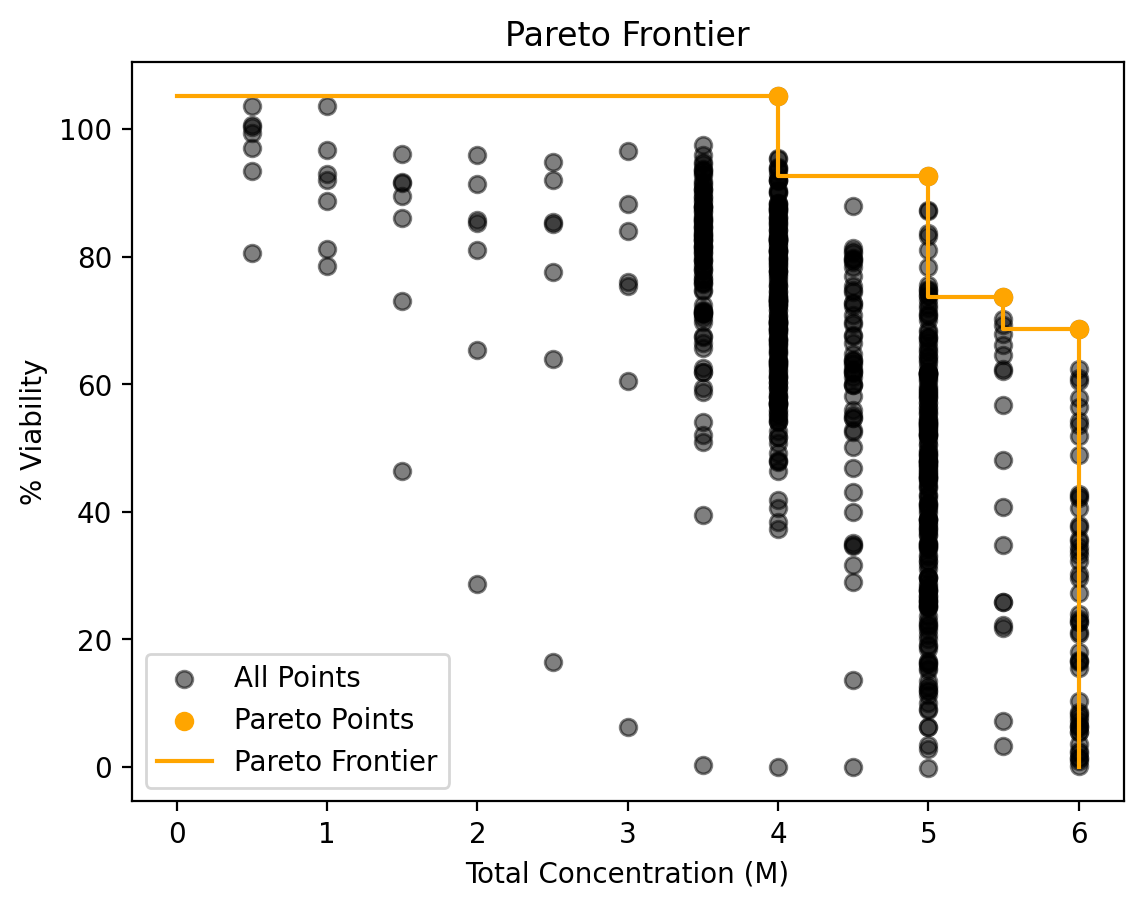

In [4]:
data = loadData()
plotPareto(data[:, -2], data[:, -1], hv = False)

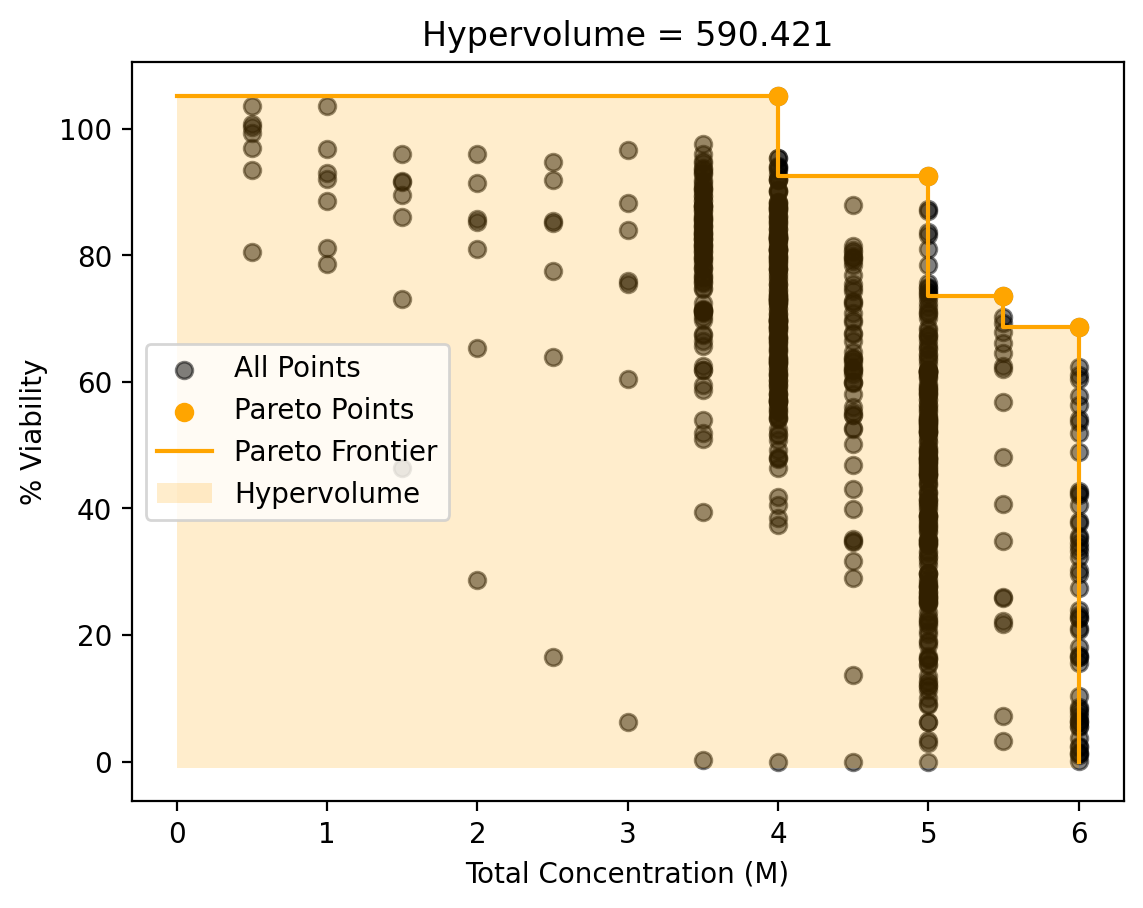

In [5]:
data = loadData()
plotPareto(data[:, -2], data[:, -1], hv = True)

In [6]:
from mlp import MLP

tkwargs = {
    'dtype': torch.float,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

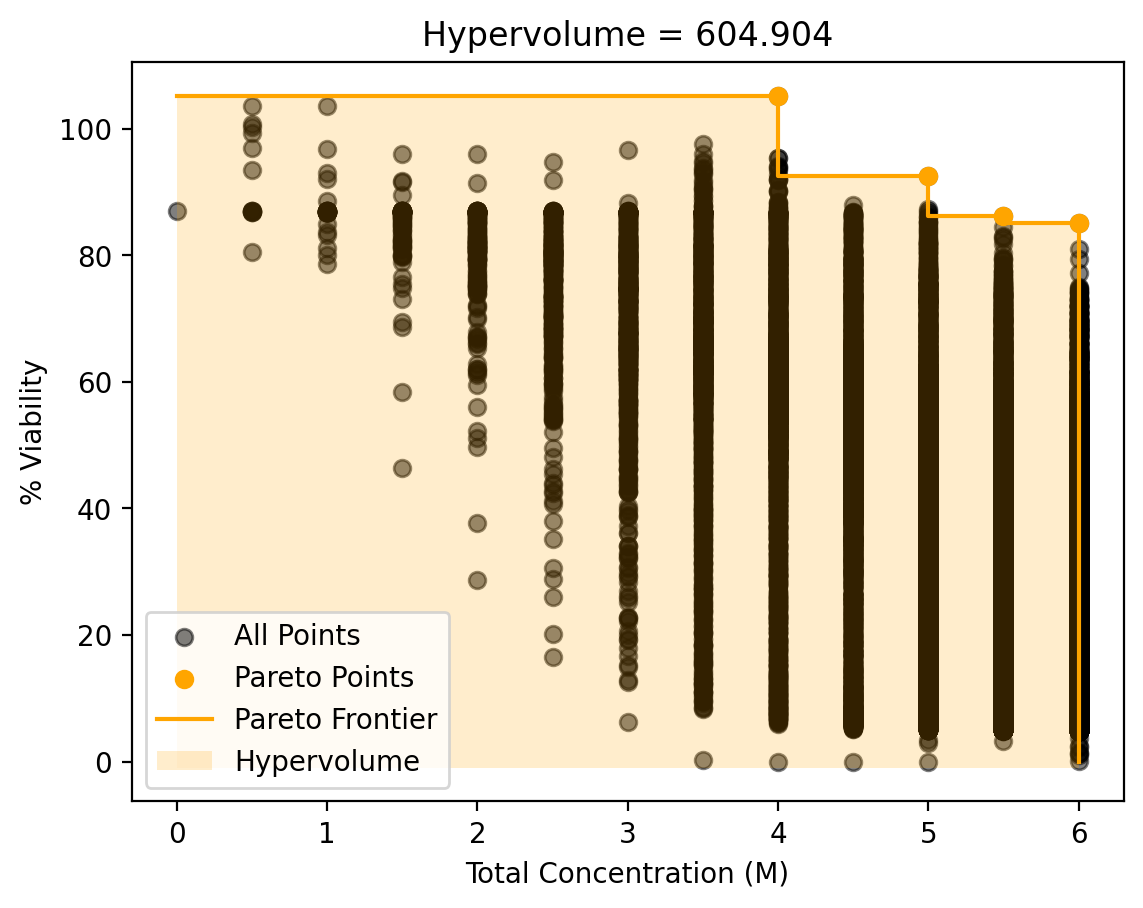

In [7]:
# See the hypervolume improvement using all of the ^M combinations and surrogate model predictions
mdl = MLP().to(**tkwargs)
mdl.load_state_dict(torch.load('models/surrogate.pth', weights_only = True))

candidates = torch.load('data/combinations-6M.pt').to(**tkwargs)

pred = mdl.predict(candidates)
conc = candidates.sum(dim=-1).unsqueeze(-1)

f1 = loadData()[:, -2]
f2 = loadData()[:, -1]

f1 = np.concatenate([f1, conc.cpu().numpy().flatten()])
f2 = np.concatenate([f2, pred.cpu().numpy().flatten()])

plotPareto(f1, f2, hv = True)

In [18]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

In [49]:
def plotBar(samples, title = None):
    samples_names = [f'CPA {i+1}' for i in range(samples.shape[0])][::-1]
    feature_names = ['Glycerol', 'DMSO', 'EG', '12PD', '13PD', '3M12PD', 'Urea']
    feature_colors = colormaps.get_cmap('tab10').colors[:samples.shape[1]]

    fig = plt.figure(figsize = (10,5))
    ax = plt.gca()

    left = torch.zeros(samples.shape[0])

    for i in range(samples.shape[1]):
        ax.barh(samples_names, samples[:, i].cpu(), color = feature_colors[i], left = left, alpha = 0.75)
        left += samples[:, i].cpu()

    ax.legend(feature_names, bbox_to_anchor=(1.0, 0.7))

    maximum = 8
    step = 0.5

    ax.set_xticks(np.arange(0, maximum + step, 2*step))
    ax.set_xticks(np.arange(step, maximum, 2*step), minor = True)
    ax.grid(axis='x', which = 'major', linestyle='-')
    ax.grid(axis='x', which = 'minor', linestyle='--')

    ax.set_xlabel('Concentration (M)')

    if title is not None:
        ax.set_title(title)

    plt.show()

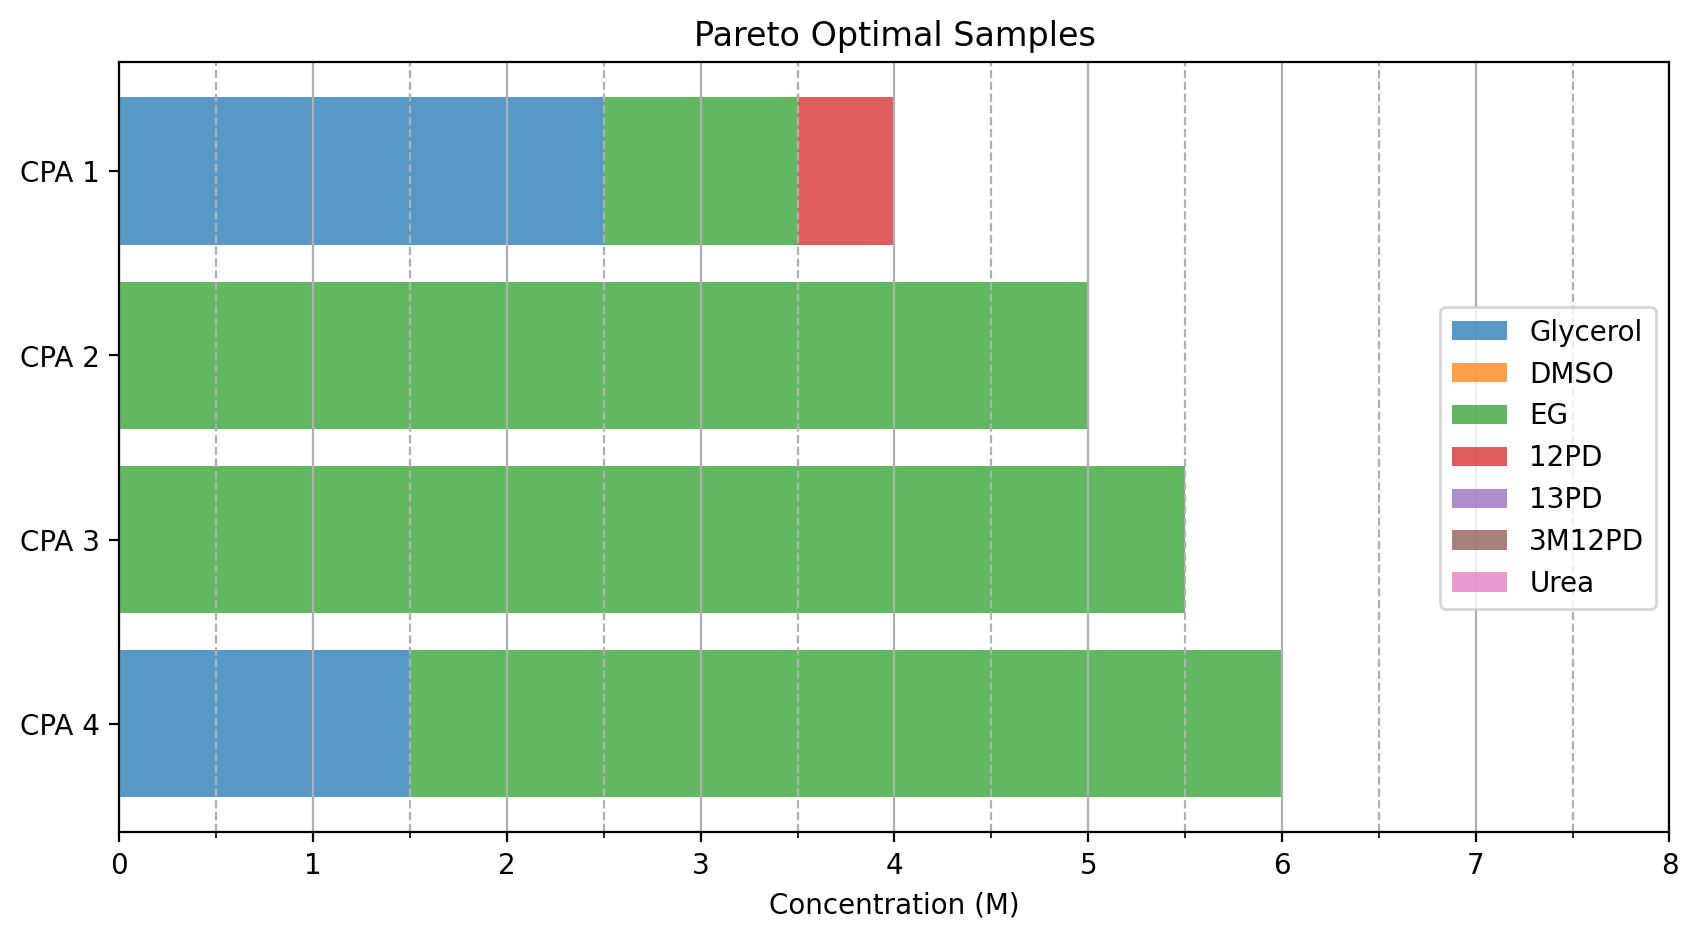

In [50]:
data = loadData()

f1 = data[:, -2]
f2 = data[:, -1]

Y = torch.cat([torch.tensor(f1).unsqueeze(-1), torch.tensor(f2).unsqueeze(-1)], dim = -1)
partitioning = DominatedPartitioning(ref_point = torch.tensor([0, -1]), Y = Y)
pareto_Y = partitioning.pareto_Y

pareto_indices = []
for point in pareto_Y:
    # Find the row index in `data` where the last two columns match the Pareto point
    index = torch.where((torch.tensor(f1) == point[0]) & (torch.tensor(f2) == point[1]))[0]
    if len(index) > 0:
        pareto_indices.append(index.item())

samples = torch.tensor(data[pareto_indices, :-2])

plotBar(samples, title = 'Pareto Optimal Samples')